In [1]:
%load_ext autoreload
%autoreload 2
import json
import os

import torch

In [2]:
dataset = "mipnerf360"  # terrasky3D, mipnerf360, scannetpp
scene = "bonsai"  # vienna_state_opera, bicycle, bonsai, graz_townhall, graz_church, 40aec5fffa

# Load dataset paths and parameters from JSON
with open("benchmarks/paths.json") as f:
    paths_cfg = json.load(f)

dataset_cfg = paths_cfg[dataset]

images_path = os.path.join(
    dataset_cfg["images_path"], scene, dataset_cfg["images_folder"]
)
base_path = dataset_cfg["base_path"]
reconstruction_path = os.path.join(
    base_path, scene, dataset_cfg["reconstruction_folder"]
)
depths_path = os.path.join(
    base_path,
    scene,
    dataset_cfg.get("depths_folder", dataset_cfg.get("depth_folder", "")),
)
gt_path = os.path.join(dataset_cfg["gt_path"], scene, dataset_cfg["gt_folder"])
opt = f"optimized_reconstruction/{scene}"

print("Images path:", images_path)
print("Reconstruction path:", reconstruction_path)
print("Depths path:", depths_path)
print("GT path:", gt_path)

Images path: /home/mattia/Desktop/datasets/mipnerf360/bonsai/images_150
Reconstruction path: /home/mattia/Desktop/Repos/batchsfm/benchmarks/vggt/mipnerf360/bonsai/sparse
Depths path: /home/mattia/Desktop/Repos/batchsfm/benchmarks/vggt/mipnerf360/bonsai/sparse/depth_maps
GT path: /home/mattia/Desktop/datasets/mipnerf360/bonsai/sparse_150


In [3]:
from epo import EPO

epo = EPO(
    reconstruction_path=reconstruction_path,
    images_path=images_path,
    depths_path=depths_path,
    single_camera_per_folder=True,
    verbose=True,
    use_amp=True,
    backend="triton",  # or "torch". Note: "triton" backend is much faster but requires a compatible GPU and PyTorch version.
)

/home/mattia/miniconda3/envs/epo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CannyEdgeDetector initialized with low_threshold=0.15, high_threshold=0.2, hysteresis=True, kernel_size=9, sigma=2, device=cuda
Found 150 images in /home/mattia/Desktop/datasets/mipnerf360/bonsai/images_150
Edges stats:
 15 images have more than 9,775 edges. 
 max: 11,164 | min: 4,242 | avg: 7,767 | std: 1,624.72 | quantiles (0.5, 0.9): 8,100, 9,775
Filtered viewgraph: 3,823/11,175 pairs retained
Average degree: 50.97, min connections 17, images with fewer than 5 neighbors: 0

Total parameters to optimize:
  t:                0
  q:                0
  mlp:         69,260
  k:                1
  z:        2,932,500
-----------------------
  Total:    3,001,761



dict_keys(['image', 'coords', 'scale', 'hw', 'depth', 'confidence', 'cam_id', 'edges_map', 'edges', 'edges_padded', 'pad_mask', 'sampled_depth', 'dt_field'])


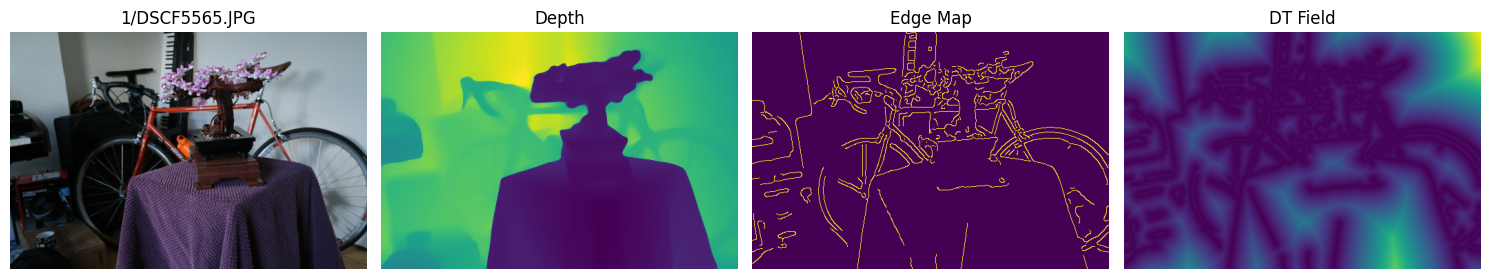

In [4]:
from mylib.plot import plot_imgs

keys = sorted(list(epo.images.keys()))
print(epo.images[keys[0]].keys())

for i in range(0, 150, 15):
    k = keys[i]
    rgb = (
        epo.images[k]["image"].permute(1, 2, 0).cpu()
        if "image" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).permute(1, 2, 0).cpu()
    )
    depth = (
        epo.images[k]["depth"].cpu()
        if "depth" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).cpu()
    )
    edges_map = (
        epo.images[k]["edges_map"].cpu()
        if "edges_map" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).cpu()
    )
    dt_field = (
        epo.images[k]["dt_field"].cpu()
        if "dt_field" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).cpu()
    )
    plot_imgs(
        [rgb, depth, edges_map, dt_field],
        titles=[k, "Depth", "Edge Map", "DT Field"],
        figsize=(15, 5),
    )
    break

In [5]:
epo(
    early_stop="pose",
    gt_path=gt_path,
)

Processing 3,823 pairs with batch size 256 (16 batches per iteration). Using 9,775 edges per image. 
 Total points to process per iteration: 37,369,825.



Optimizing:   2%|▏         | 49/2000 [00:03<01:29, 21.88it/s, auc5=69.6381, loss=4.9660]

Pose convergence reached at step 48.


Optimizing:  18%|█▊        | 368/2000 [00:19<01:25, 19.06it/s, auc5=91.1936, loss=3.9415]


Stopping optimization at step 368. Convergence reached.

                          EPO  Summary                           
-----------------------------------------------------------------
                             LOADING                             
-----------------------------------------------------------------
  images                           837.4ms  22.6%              
  depth maps                       214.8ms   5.8%              
  poses & intrinsics               162.6ms   4.4%              
  edges                              1.08s  29.2%              
  distance fields                  485.2ms  13.1%              
  viewgraph                        576.2ms  15.6%              
  other (extractor load, GC…)      342.4ms   9.3%              
total loading                        3.70s  16.1%              
-----------------------------------------------------------------
                       OPTIMIZATION  LOOP                        
-----------------------------------

Max AUC@5: 91.19355715367972


(<Figure size 2400x300 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Optimization steps', ylabel='Change'>], dtype=object))

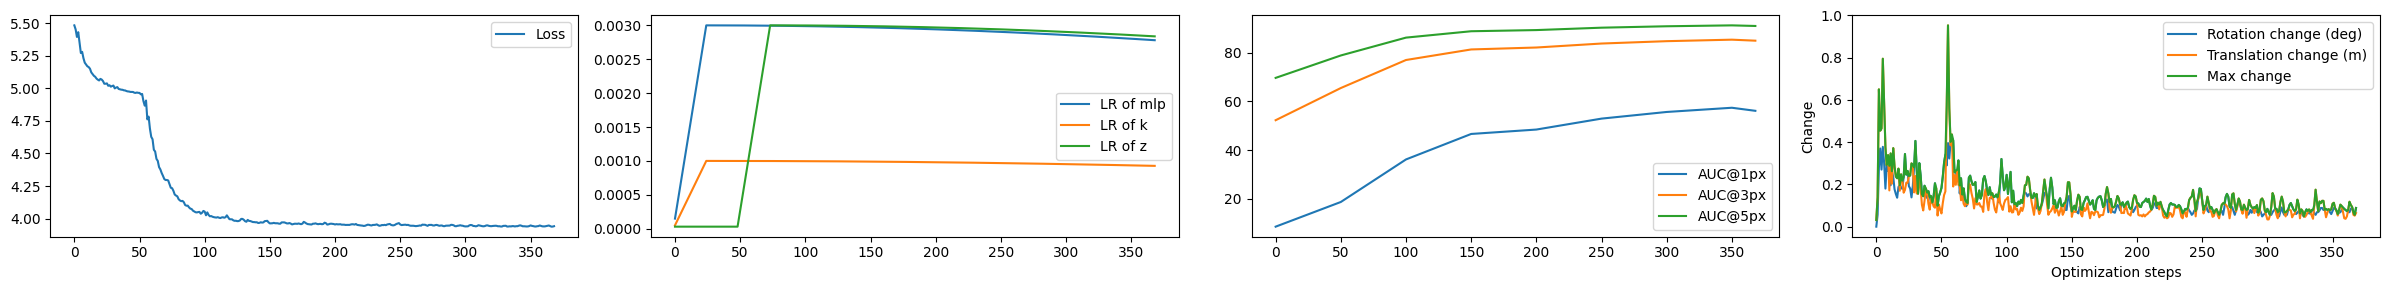

In [6]:
from helpers.demo_plotting import plot_training_summary

plot_training_summary(epo, auc_thresholds=(1, 3, 5))

(<Figure size 1400x400 with 2 Axes>,
 <Axes: title={'center': 'Training Convergence & Stability Metrics'}, xlabel='Steps', ylabel='Max Change (Delta)'>)

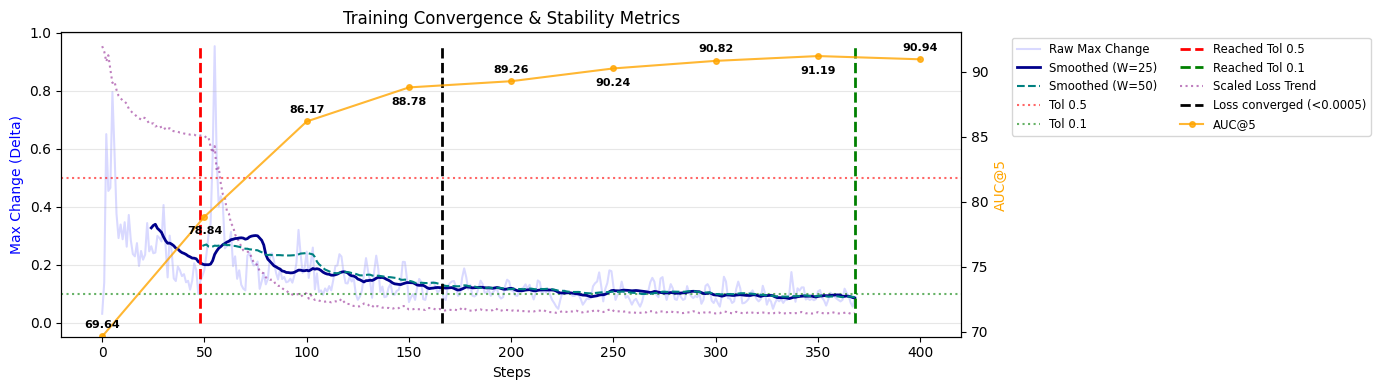

In [7]:
from helpers.demo_plotting import plot_training_convergence

# `epo` works as-is; pass a "training_logs.json" path or dict to replay a run.
plot_training_convergence(
    epo,
    window_pose=25,
    window_pose2=50,
    window_loss=25,
    tol_pose=0.5,
    tol_pose2=0.1,
    tol_loss=5e-4,
)

In [8]:
opt = f"optimized_reconstruction/{scene}/sparse"
os.makedirs(opt, exist_ok=True)

save_points = True  # recall to set mean track len = 0 in colmap gui

epo.to_colmap(
    opt,
    verbose=False,
    max_points_per_image=100_000 // len(epo.images),
    save_points=save_points,
    final_dbscan_filtering=False,
    dbscan_eps=0.1,
    dbscan_min_samples=5,
)

Reconstruction(num_cameras=1, num_images=150, num_reg_images=150, num_points3D=99900)

In [9]:
from helpers.benchmark_pose import eval_colmap_model

thresholds = [1, 3, 5]
print("AUC@", thresholds)

AUC_score_max, num_images, df_initial = eval_colmap_model(
    reconstruction_path, gt_path, return_df=True, thrs=thresholds
)
print("VGGT AUC:   ", [float(round(_, 2)) for _ in AUC_score_max])

try:
    ba = reconstruction_path.replace("vggt", "vggt_ba")
    AUC_score_max, num_images, df_ba = eval_colmap_model(
        ba, gt_path, return_df=True, thrs=thresholds
    )
    print("VGGT+BA AUC:", [float(round(_, 2)) for _ in AUC_score_max])
    ba_ref = reconstruction_path.replace("vggt", "vggt_ba_ref")
    AUC_score_max, num_images, df_ba = eval_colmap_model(
        ba_ref, gt_path, return_df=True, thrs=thresholds
    )
    print("VGGT+BA Ref:", [float(round(_, 2)) for _ in AUC_score_max])
except Exception:
    df_ba = None
    print("No BA reconstruction found.")

AUC_score_max, num_images, df_optim = eval_colmap_model(
    opt, gt_path, return_df=True, thrs=thresholds
)
print("VGGT+EA AUC:", [float(round(_, 2)) for _ in AUC_score_max])

AUC@ [1, 3, 5]
VGGT AUC:    [8.9, 52.44, 69.74]
VGGT+BA AUC: [40.23, 79.46, 87.66]
VGGT+BA Ref: [40.6, 79.62, 87.76]
VGGT+EA AUC: [56.12, 84.91, 90.94]
